## Get and Format Data
### Only do this once (until someone changes the code)
1. Run all blocks in notebooks/bipartite_graph.ipynb
2. cd into notebooks
2. Run process_graphs.py
3. Run run_simulations.py (there are hyperparameters on the number of trajectories to simulate and expansion types)
4. Run this notebook

### Setting to GPU

In [1]:
import torch

# Move dataloaders to GPU IF AVAILABLE
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


### Imports

In [2]:
# General imports
import sys
import os
import numpy as np

# PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv 
from torch_geometric.nn import GATv2Conv


# ----File Stitching----
# If in models folder, cd back to notebooks folder
if os.path.basename(os.getcwd()) == "models":
    os.chdir('..')
# If a file is in /src/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Import from .py files 
from training import load_and_prepare_training_data, ImitationTrainer # Training script handles dataloaders 
train_dataloader, val_dataloader, static_graph = load_and_prepare_training_data()
node_dim = static_graph['x_static'].shape[1] + 1 
_, _, _, sample_event_feat = next(iter(train_dataloader))
event_dim = sample_event_feat.shape[1]

Loading imitation data...
Splitting data with 20.0% validation ratio...
Building PyTorch Train DataLoader...
Loading static graph topology...
Aligning static user features...


c:\Users\student\Desktop\ml3\contagion-seeding-in-meetup\notebooks\..\src\preprocess.py:292: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  'edge_index_1': torch.load(os.path

Aligning event features...
Building PyTorch Validation DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...


## Define Model

#### Input: Simple and Hyper Graphs

In [3]:
# Adapted code from 
    # https://towardsdatascience.com/graph-attention-networks-in-python-975736ac5c0c/
    # https://www.github.com/diegoantognini/pyGAT/blob/master/

# Define a Graph Attention Model class
class GAT_hybrid(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=1, edge_dim=1): # Maybe increase num heads later?
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, edge_dim=edge_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim * heads, heads=heads, edge_dim=edge_dim)
        self.gat3 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, edge_dim=edge_dim)
        # Implement weight decay to limit overfitting
        self.optmizer = torch.optim.Adam(self.parameters(), lr=0.001,weight_decay=0.001)

    def forward(self,x_batch, static_graph, event_feat_batch): 
        # Obtain x_batch dimensions
        B, N, _ = x_batch.shape
        # print(f"{B=}, {N=}")
        x_nodes_list =[]
        # For each node in x_batch, run it through a Gatv2Conv layer
        for b in range(B):
            x_b = x_batch[b]
            h = F.dropout(x_b, p=0.2, training=self.training)
            # One GATv2Conv layer for simple graph input
            h = self.gat1(x_b, static_graph['edge_index_1'],static_graph['edge_attr_1'])
            h = F.elu(h)
            h = F.dropout(h, p=0.2, training=self.training) # h.shape=torch.Size([24591, 9]) 
            # print(f"{h.shape=}")
            # Second GATv2Conv layer for hypergraph input
            h = self.gat2(h, static_graph['edge_index_2'],static_graph['edge_attr_2'])
            h = F.elu(h)
            # print(f"{h.shape=}")
            # Third layer for simple graph again
            h = self.gat2(h, static_graph['edge_index_1'],static_graph['edge_attr_1'])
            h = F.elu(h)    
            # print(f"{h.shape=}")
    
            # Fourth, final layer for hypergraph
            h = self.gat3(h,static_graph['edge_index_2'],static_graph['edge_attr_2'])
            x_nodes_list.append(h)
        # Combine all the nodes into a single tensor
        batch_x_nodes = torch.stack(x_nodes_list)
        batch_x_nodes = batch_x_nodes.squeeze(2)
        return batch_x_nodes

## Run Training Script

#### Input: Simple and Hyper Graphs


Initializing model with Node Dim: 9, Event Dim: 64

--------TESTING LEARNING RATE 1e-05 AND WEIGHT DECAY 1e-05--------


Starting Training...
Starting training on cuda...


New best model saved at epoch 1 (Val BCE: 13.9435)
Epoch 1/4 | Train BCE: 47.0725 | Val BCE: 13.9435


New best model saved at epoch 2 (Val BCE: 13.7880)
Epoch 2/4 | Train BCE: 47.4860 | Val BCE: 13.7880


New best model saved at epoch 3 (Val BCE: 13.4591)
Epoch 3/4 | Train BCE: 45.7976 | Val BCE: 13.4591


Epoch 4/4 | Train BCE: 45.4802 | Val BCE: 13.9176
Training complete.
Loss curve saved to weights\imitation_model_GAT_hybrid_1776282953\loss_curve.png

--------TESTING LEARNING RATE 1e-05 AND WEIGHT DECAY 1e-05--------


Starting Training...
Starting training on cuda...


...

New best model saved at epoch 4 (Val BCE: 0.3856)
Epoch 4/4 | Train BCE: 0.4074 | Val BCE: 0.3856
Training complete.
Loss curve saved to weights\imitation_model_GAT_hybrid_1776286391\loss_curve.png

--------TESTING LEARNING RATE 0.1 AND WEIGHT DECAY 0.1--------


Starting Training...
Starting training on cuda...


New best model saved at epoch 1 (Val BCE: 0.4180)
Epoch 1/4 | Train BCE: 0.4386 | Val BCE: 0.4180


New best model saved at epoch 2 (Val BCE: 0.4112)
Epoch 2/4 | Train BCE: 0.4016 | Val BCE: 0.4112


Epoch 3/4 | Train BCE: 0.4164 | Val BCE: 0.4367


New best model saved at epoch 4 (Val BCE: 0.3961)
Epoch 4/4 | Train BCE: 0.4149 | Val BCE: 0.3961
Training complete.
Loss curve saved to weights\imitation_model_GAT_hybrid_1776286872\loss_curve.png

--------BEST LEARNING RATE: 0.1
BEST WEIGHT DECAY: 0.001--------


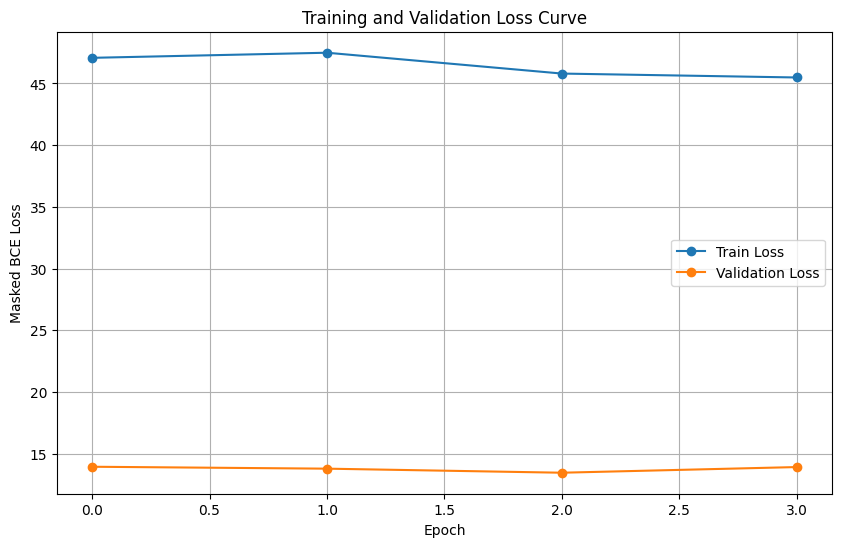

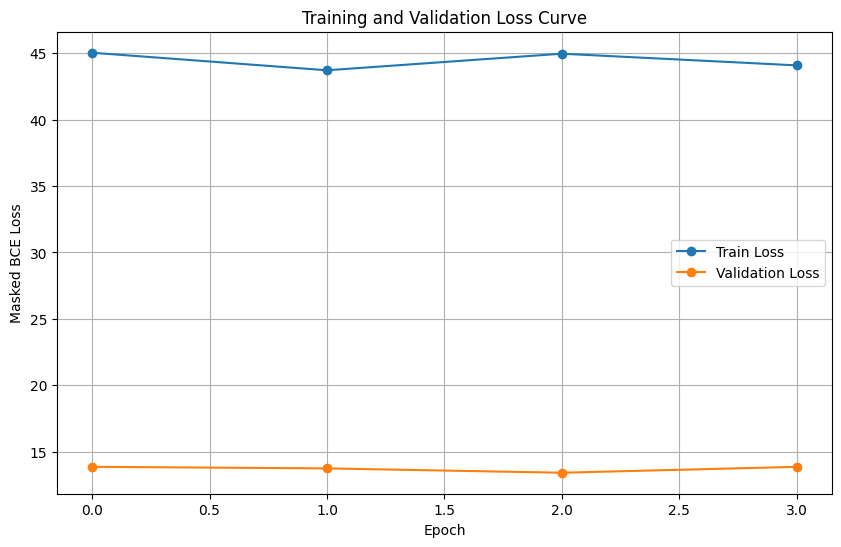

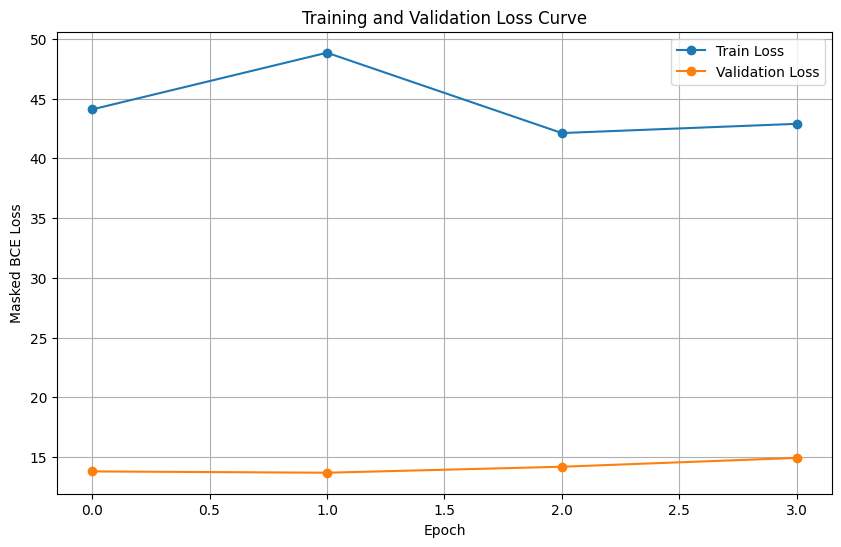

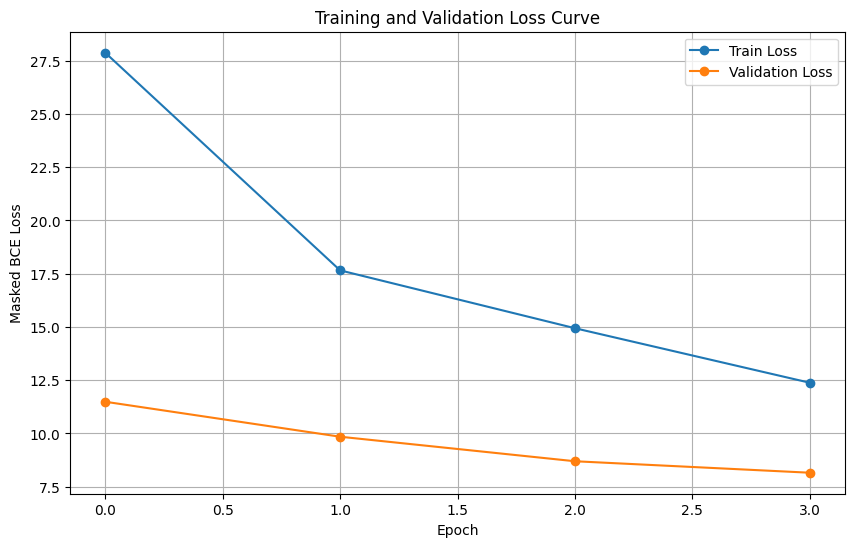

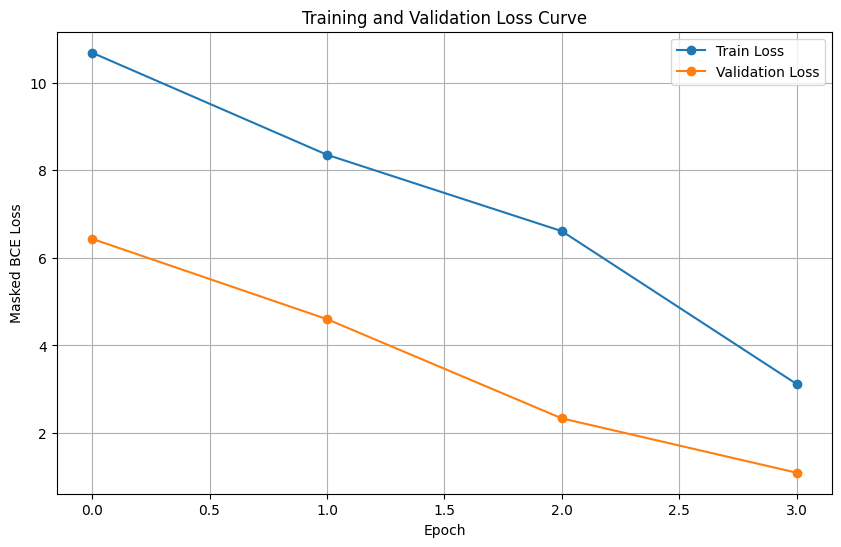

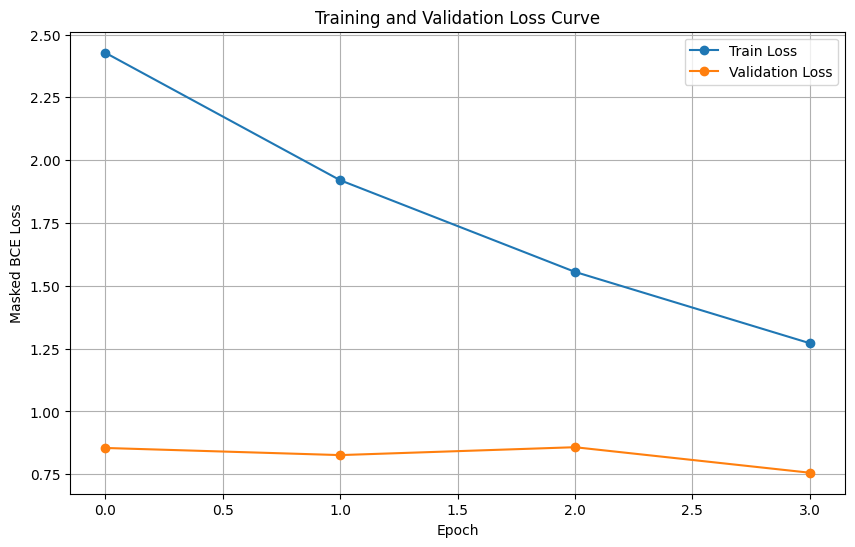

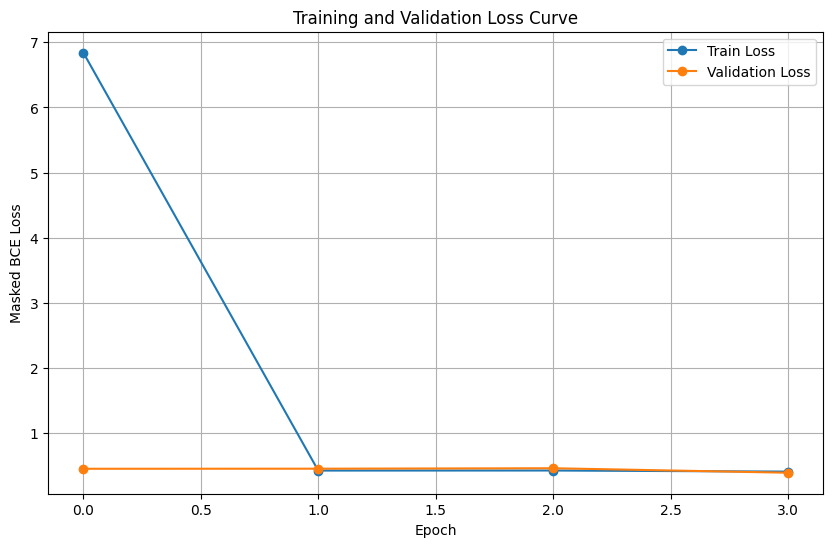

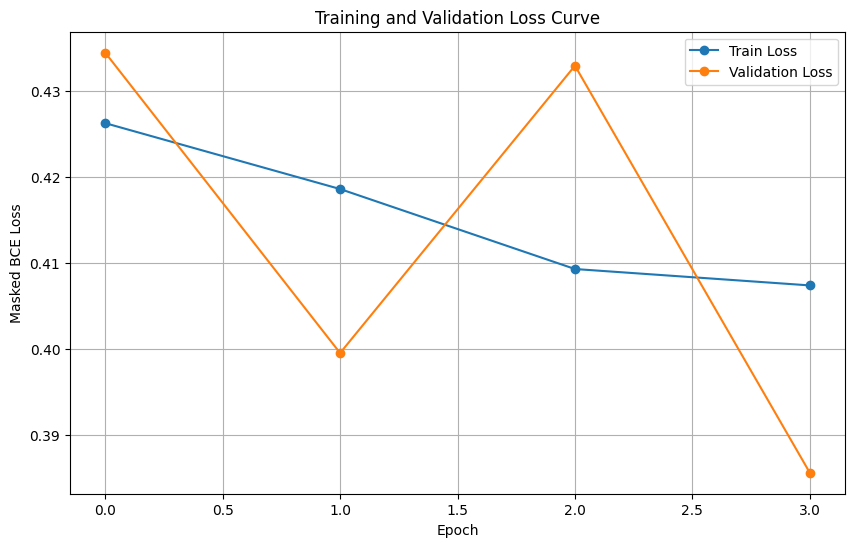

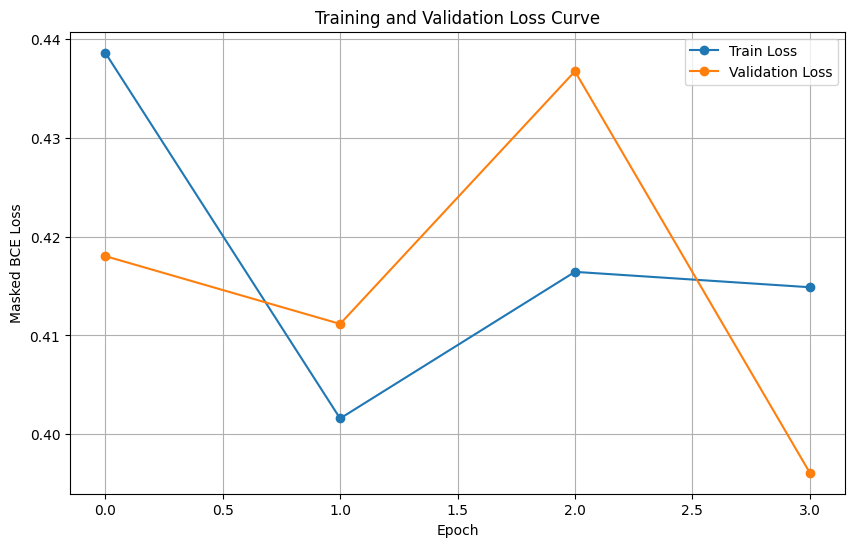

In [4]:
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model_hybrid = GAT_hybrid(
    in_dim = -1,
    hidden_dim = 8,
    out_dim = 1
)

model_hybrid.to(device)

learning_rates = [1e-5, 1e-3, 1e-1]
weight_decays = [1e-5, 1e-3, 1e-1]
all_train_losses = []; all_val_losses = []
best_model = None
best_trainer = None
best_loss = np.inf

for i in range(len(learning_rates)):

    for j in range(len(weight_decays)):
        
        config = {
                    'lr': learning_rates[i],
                    'weight_decay': weight_decays[j],
                    'epochs': 4, # 4 epochs sufficient for hyperparameter tuning
                    'steps_per_epoch': 16,
                    'val_batches': 4,
                    'early_stopping_patience': 10,
                    'early_stopping_delta': 0.0001,
                    'project_name': 'meetup-contagion-seeding',
                    'run_name': 'GAT_hybrid_run'
                }
        
        print(f"\n--------TESTING LEARNING RATE {learning_rates[i]} AND WEIGHT DECAY {weight_decays[i]}--------\n")

        trainer_hybrid = ImitationTrainer(
            device=device,
            model=model_hybrid,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            static_graph=static_graph,
            config=config,
            use_wandb=False # Switch to False if wandb is not set up
        )

        print("\nStarting Training...")
        trainer_hybrid.train()
        all_train_losses.append(trainer_hybrid.history['train_loss'])
        all_val_losses.append(trainer_hybrid.history['val_loss'])

        if np.min(trainer_hybrid.history['val_loss']) < best_loss:
            best_loss = np.min(trainer_hybrid.history['val_loss'])
            best_lr = learning_rates[i]
            best_weight_decay = weight_decays[j]
            best_trainer = trainer_hybrid
            best_model = model_hybrid

print(f"\n--------BEST LEARNING RATE: {best_lr}\nBEST WEIGHT DECAY: {best_weight_decay}--------")


Initializing model with Node Dim: 9, Event Dim: 64
Utilizing learning rate: 0.1, weight decay: 0.001

Starting Training...
Starting training on cuda...


New best model saved at epoch 1 (Val BCE: 0.4459)
Epoch 1/50 | Train BCE: 0.5348 | Val BCE: 0.4459


New best model saved at epoch 2 (Val BCE: 0.4172)
Epoch 2/50 | Train BCE: 0.4030 | Val BCE: 0.4172


Epoch 3/50 | Train BCE: 0.4171 | Val BCE: 0.4320


New best model saved at epoch 4 (Val BCE: 0.3868)
Epoch 4/50 | Train BCE: 0.3994 | Val BCE: 0.3868


...

Epoch 8/50 | Train BCE: 0.4135 | Val BCE: 0.4070


Epoch 9/50 | Train BCE: 0.3967 | Val BCE: 0.4037


Epoch 10/50 | Train BCE: 0.4047 | Val BCE: 0.3955


Epoch 11/50 | Train BCE: 0.4121 | Val BCE: 0.4030


Stopping early as no improvement has been observed.
Early stopping at epoch 11
Training complete.
Loss curve saved to weights\imitation_model_GAT_hybrid_1776287351\loss_curve.png


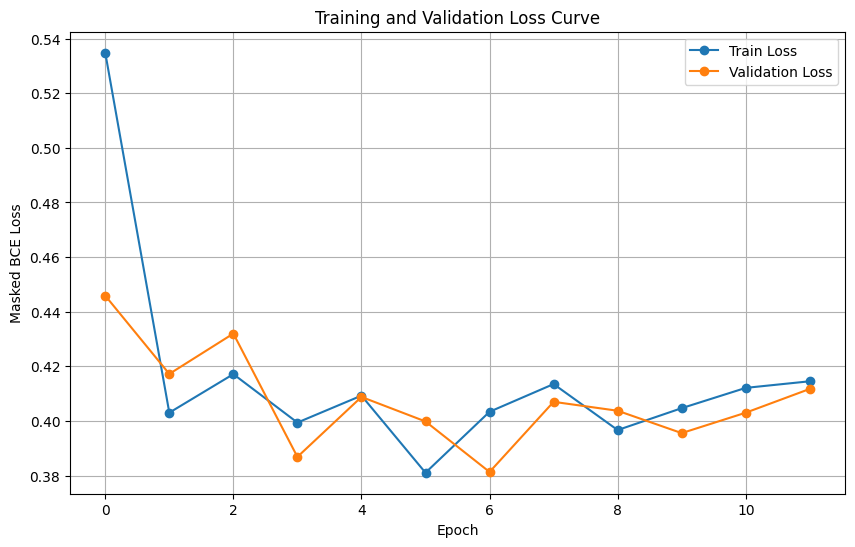

In [5]:
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")
print(f"Utilizing learning rate: {best_lr}, weight decay: {best_weight_decay}")

model_hybrid_best = GAT_hybrid(
    in_dim = -1,
    hidden_dim = 8,
    out_dim = 1
)

model_hybrid_best.to(device)


config = {
            'lr': best_lr,
            'weight_decay': best_weight_decay,
            'epochs': 50, # Move to 50 for utilizing best lr and weight decay
            'steps_per_epoch': 16,
            'val_batches': 4,
            'early_stopping_patience': 5, 
            'early_stopping_delta': 0.001,
            'project_name': 'meetup-contagion-seeding',
            'run_name': 'GAT_hybrid_best_run'
        }


trainer_hybrid_best = ImitationTrainer(
    device=device,
    model=model_hybrid,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    static_graph=static_graph,
    config=config,
    use_wandb=False # Switch to False if wandb is not set up
)

print("\nStarting Training...")
trainer_hybrid_best.train()